In [1]:
import pandas as pd 
import numpy as np


In [2]:
sentiment=pd.read_csv('/Users/prabhakarsingour/kundli/oas/primetrade.ai/data/fear_greed_index.csv')
trades=pd.read_csv('/Users/prabhakarsingour/kundli/oas/primetrade.ai/data/historical_data.csv')

In [3]:
print(sentiment.head())
print(sentiment.info())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None


In [4]:
print(trades.head())
print(trades.info())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [5]:
print(sentiment.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [6]:
# clean column names
sentiment.columns = sentiment.columns.str.strip().str.lower()
trades.columns = trades.columns.str.strip().str.lower()

# replace spaces with underscores (VERY IMPORTANT)
trades.columns = trades.columns.str.replace(" ", "_")
sentiment.columns = sentiment.columns.str.replace(" ", "_")

print("Sentiment:", sentiment.columns)
print("Trades:", trades.columns)

Sentiment: Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Trades: Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')


In [7]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [8]:
trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], format='mixed', dayfirst=True)
trades['date'] = trades['timestamp_ist'].dt.date

In [9]:
df = pd.merge(trades, sentiment, on="date", how="left")
print(df.head())

                                      account  coin  execution_price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   size_tokens  size_usd side       timestamp_ist  start_position direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   closed_pnl                                   transaction_hash     order_id  \
0         0

In [10]:
print(df.groupby('classification')['closed_pnl'].mean())

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: closed_pnl, dtype: float64


In [11]:
df['is_profit'] = df['closed_pnl'] > 0

print(df.groupby('classification')['is_profit'].mean())

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: is_profit, dtype: float64


In [12]:
print(df.groupby('classification')['size_usd'].mean())

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: size_usd, dtype: float64


In [13]:
print(pd.crosstab(df['classification'], df['side']))

side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


***PLOTS***

/Users/prabhakarsingour/.matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /var/folders/6s/2bp_1zp560l5n724jxb__ml40000gn/T/matplotlib-pkyadwxn because there was an issue with the default path (/Users/prabhakarsingour/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


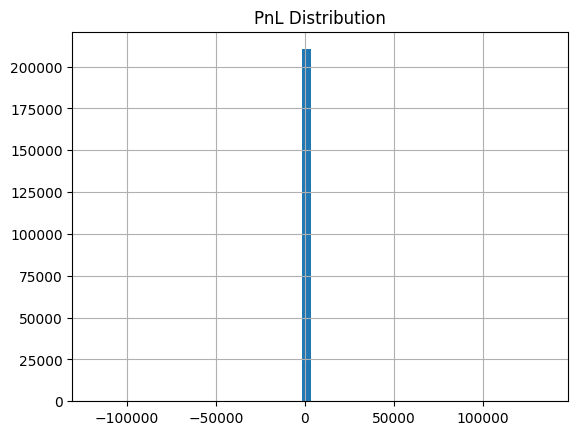

In [14]:
import matplotlib.pyplot as plt

df['closed_pnl'].hist(bins=50)
plt.title("PnL Distribution")
plt.show()

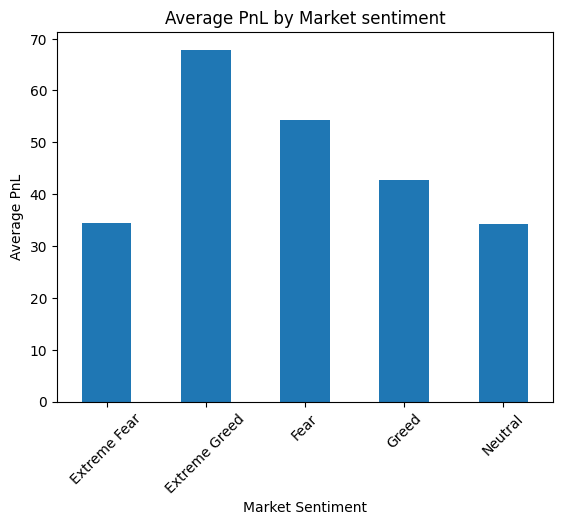

In [15]:
pnl_by_sentiment=df.groupby('classification')['closed_pnl'].mean()
pnl_by_sentiment.plot(kind='bar')
plt.title("Average PnL by Market sentiment")
plt.ylabel("Average PnL")
plt.xlabel("Market Sentiment")
plt.xticks(rotation=45)
plt.show()

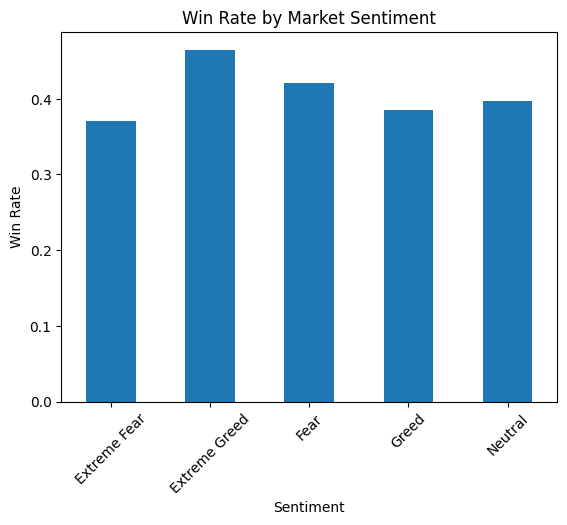

In [16]:
win_rate = df.groupby('classification')['is_profit'].mean()

win_rate.plot(kind='bar')
plt.title("Win Rate by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Win Rate")
plt.xticks(rotation=45)
plt.show()

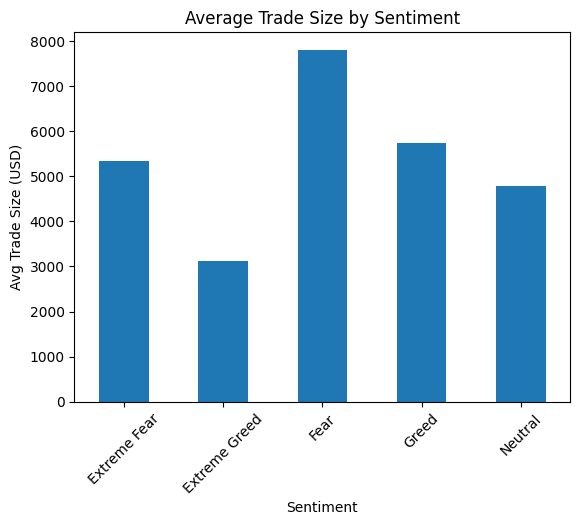

In [17]:
size = df.groupby('classification')['size_usd'].mean()

size.plot(kind='bar')
plt.title("Average Trade Size by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Avg Trade Size (USD)")
plt.xticks(rotation=45)
plt.show()

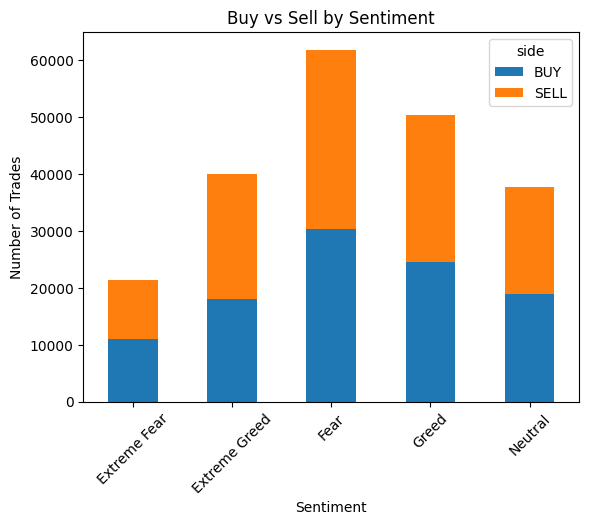

In [18]:
side_dist = pd.crosstab(df['classification'], df['side'])

side_dist.plot(kind='bar', stacked=True)
plt.title("Buy vs Sell by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)
plt.show()

Note: you may need to restart the kernel to use updated packages.


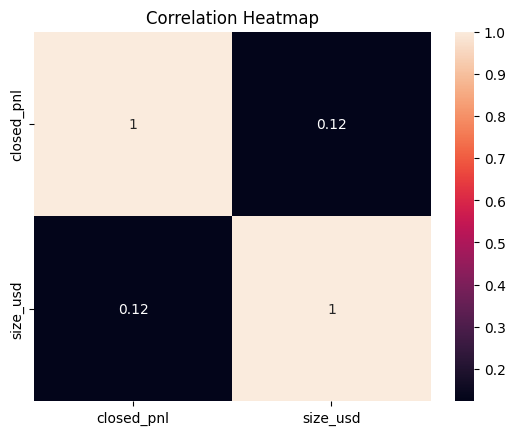

In [19]:
%pip install seaborn
import seaborn as sns

# select numeric columns
num_df = df[['closed_pnl', 'size_usd']]

sns.heatmap(num_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

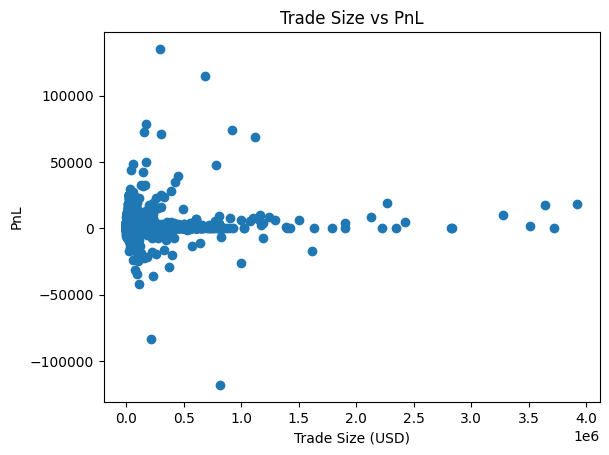

In [20]:
plt.scatter(df['size_usd'], df['closed_pnl'])
plt.title("Trade Size vs PnL")
plt.xlabel("Trade Size (USD)")
plt.ylabel("PnL")
plt.show()

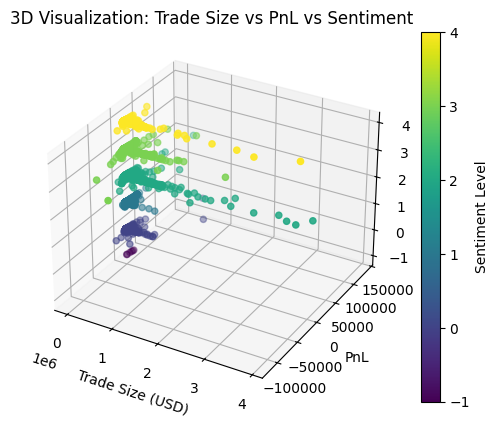

In [21]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Encode sentiment
df['sentiment_encoded'] = df['classification'].astype('category').cat.codes

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['size_usd'],
    df['closed_pnl'],
    df['sentiment_encoded'],
    c=df['sentiment_encoded']
)

fig.colorbar(scatter, label="Sentiment Level")

ax.set_xlabel("Trade Size (USD)")
ax.set_ylabel("PnL")
ax.set_zlabel("Sentiment (Encoded)")
ax.set_title("3D Visualization: Trade Size vs PnL vs Sentiment")

plt.show()

In [22]:
import plotly.express as px

fig = px.scatter_3d(
    df.sample(5000),
    x='size_usd',
    y='closed_pnl',
    z='classification',
    color='classification',
    title="Interactive 3D: Trade Size vs PnL vs Sentiment"
)

fig.show()